In [90]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [91]:
# pip install seaborn matplotlib plotly scikit-learn

numpy, pandas,seaborn, matplotlib, plotly,scikit-learn

# 1) Data Aquistion

In [92]:
# Cleaning and Preprocessing

In [93]:
BS=pd.read_csv("boston.csv")

In [94]:
BS.columns

Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='str')

In [95]:
BS.drop('Unnamed: 0',axis=1,inplace=True)

In [96]:
BS.dtypes # Machine Learn only numeric records and all columns are numeric
# hence no typecasting required

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
Price      float64
dtype: object

In [97]:
BS.isnull().sum() # no missing value

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

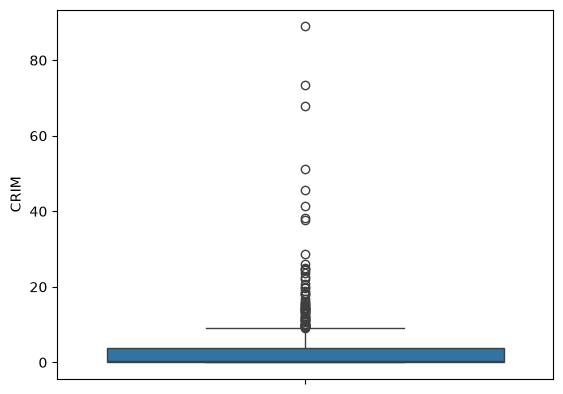

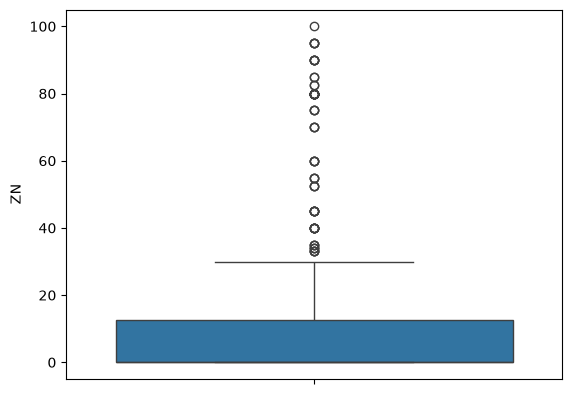

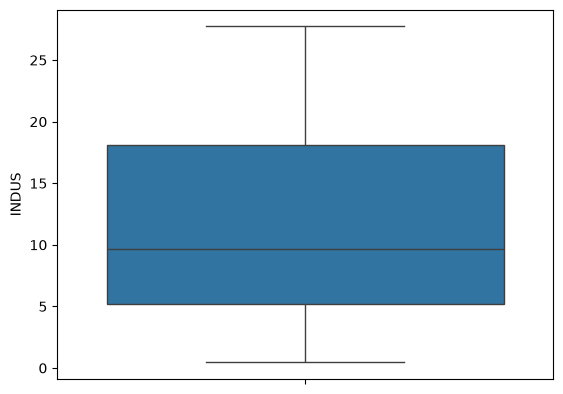

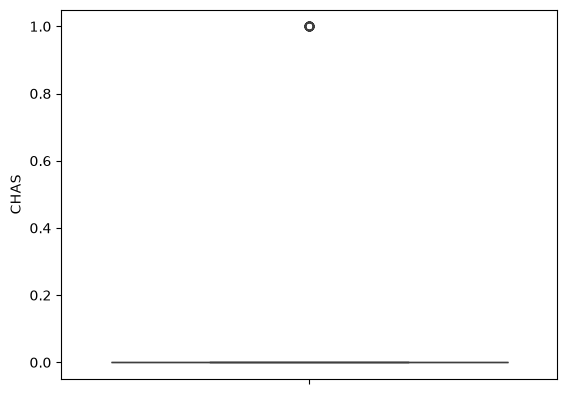

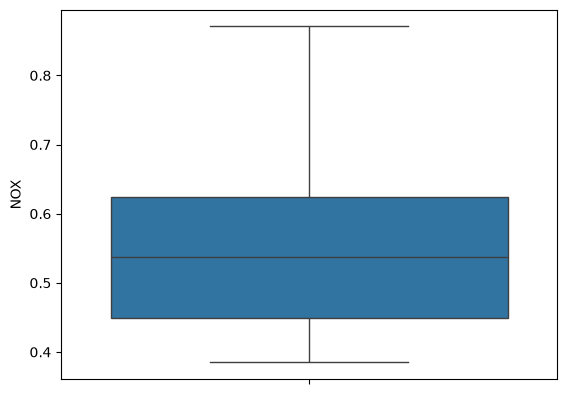

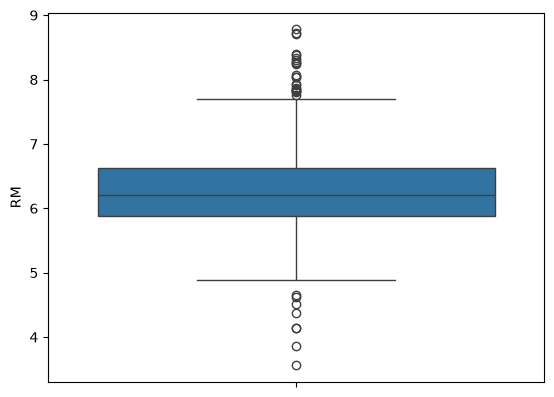

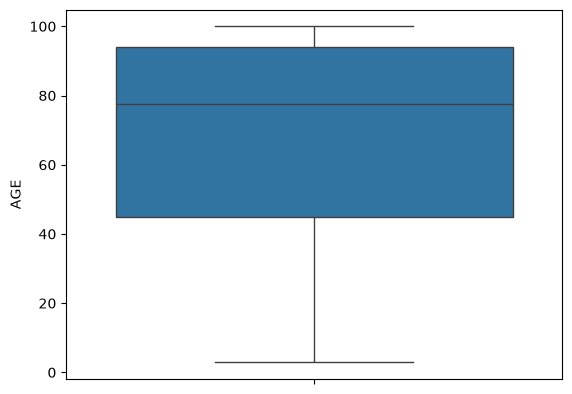

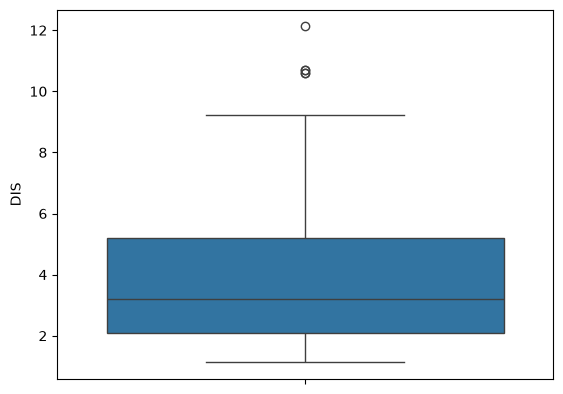

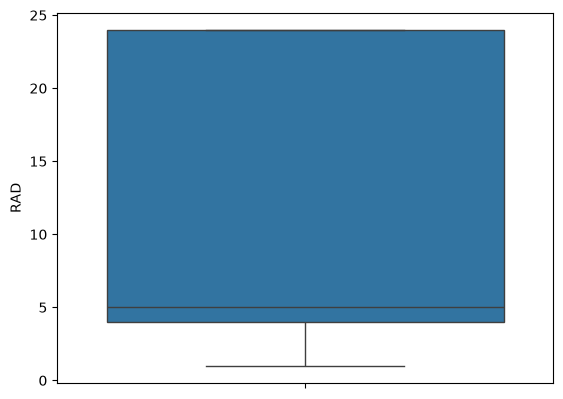

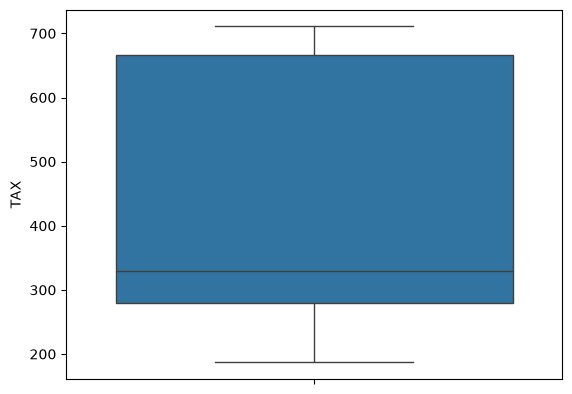

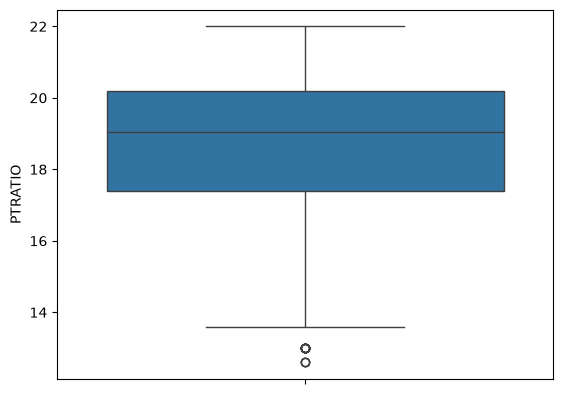

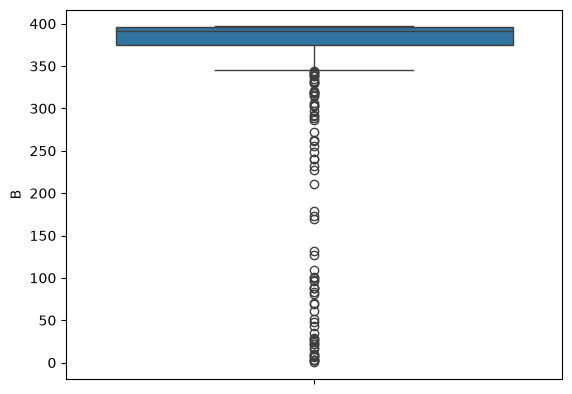

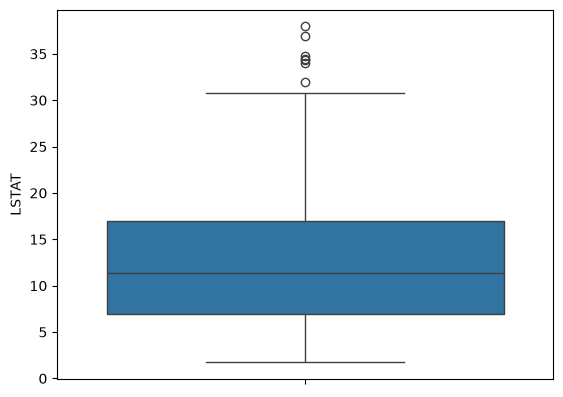

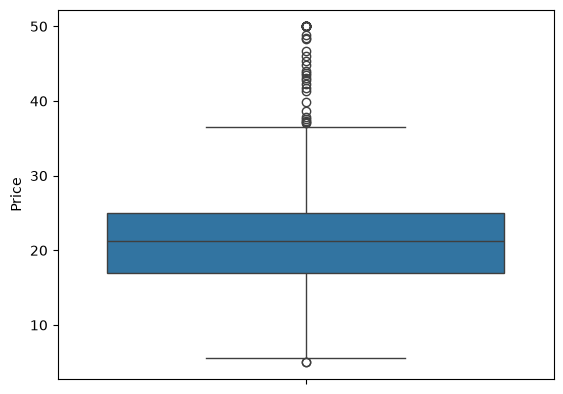

In [98]:
for col in BS.columns:    # Data contains outliers
    sns.boxplot(BS[col])
    plt.show()

# Zscore Method

In [99]:
Brows= BS.shape[0]


In [100]:
Brows

506

In [101]:
for col in BS.columns:
    STD3= BS[col].std()*3
    Mean= BS[col].mean()
    Lower= Mean-(STD3)
    Upper= Mean+(STD3)
    Index= BS[col].between(Lower,Upper)
    BS= BS[Index]
    print(f"Column{col} Rows{BS.shape[0]}")
    

ColumnCRIM Rows498
ColumnZN Rows484
ColumnINDUS Rows484
ColumnCHAS Rows450
ColumnNOX Rows450
ColumnRM Rows441
ColumnAGE Rows441
ColumnDIS Rows437
ColumnRAD Rows437
ColumnTAX Rows437
ColumnPTRATIO Rows437
ColumnB Rows414
ColumnLSTAT Rows412
ColumnPrice Rows404


In [102]:
Arows=BS.shape[0]

In [103]:
Arows

404

In [104]:
print(f'Before outlier Removal{Brows}After outlier Removal{Arows}')

Before outlier Removal506After outlier Removal404


In [105]:
404/506

0.7984189723320159

In [106]:
STD3

np.float64(23.77217448353075)

In [107]:
Mean

np.float64(22.258980582524273)

In [108]:
Lower

np.float64(-1.5131939010064777)

In [109]:
Upper

np.float64(46.03115506605502)

In [110]:
BS["Price"].unique()

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 13.6, 19.6, 15.2, 14.5,
       15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 13.2, 13.1, 13.5, 20. ,
       24.7, 30.8, 34.9, 26.6, 25.3, 21.2, 19.3, 14.4, 19.4, 19.7, 20.5,
       25. , 23.4, 23.3, 18.7, 16. , 22.2, 33. , 23.5, 22. , 17.4, 20.9,
       24.2, 22.8, 24.1, 21.4, 20.8, 20.3, 28. , 23.9, 24.8, 22.5, 23.6,
       22.6, 20.6, 28.4, 38.7, 43.8, 33.2, 27.5, 26.5, 20.1, 19.5, 19.8,
       18.8, 18.5, 18.3, 19.2, 17.3, 15.7, 16.2, 18. , 14.3, 23. , 18.1,
       17.1, 13.3, 17.8, 14. , 11.8, 13.8, 14.6, 15.4, 21.5, 41.3, 24.3,
       22.7, 23.8, 22.3, 19.1, 29.4, 23.2, 24.6, 29.9, 37.2, 39.8, 37.9,
       32.5, 26.4, 29.6, 32. , 29.8, 37. , 30.5, 36.4, 31.1, 29.1, 33.3,
       30.3, 34.6, 24.4, 28.1, 23.7, 30.1, 44.8, 37.6, 31.6, 31.5, 31.7,
       17.6, 24.5, 26.2, 42.8, 21.9, 36. , 33.8, 43.1, 31. , 36.5, 30.7,
       43.5, 21.1, 25.2, 35.1, 45.4, 35.4, 28.5, 37

In [111]:
X=BS.drop("Price",axis=1)
Y=BS.Price

In [112]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [113]:
MMS= MinMaxScaler()
X_Norm= MMS.fit_transform(X)

In [114]:
X_Norm = pd.DataFrame(data=X_Norm,columns=X.columns)

<Axes: >

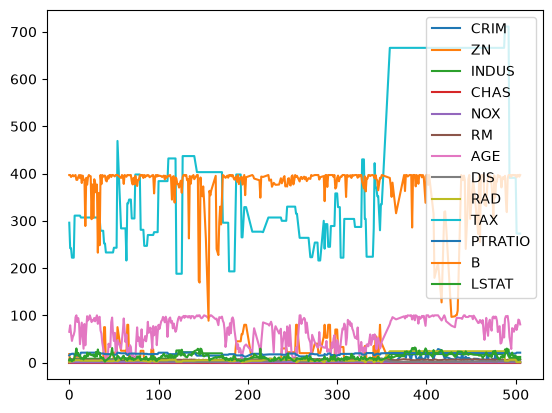

In [115]:
X.plot()

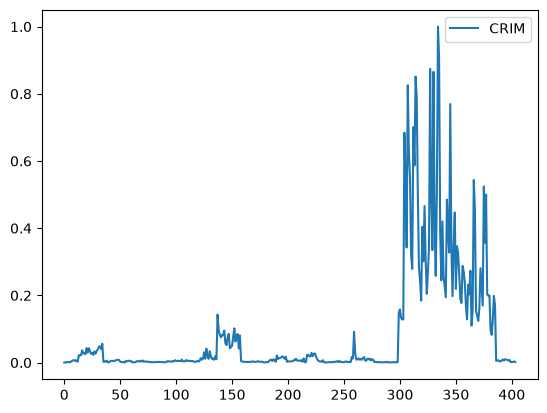

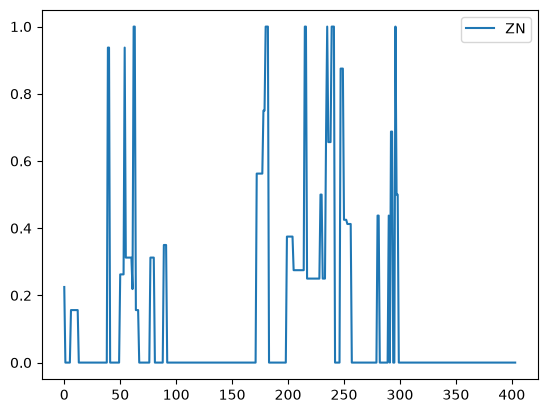

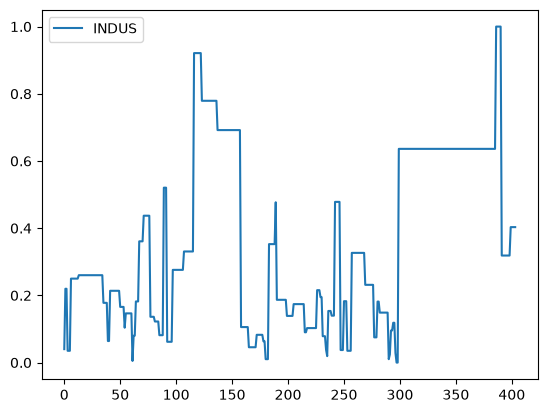

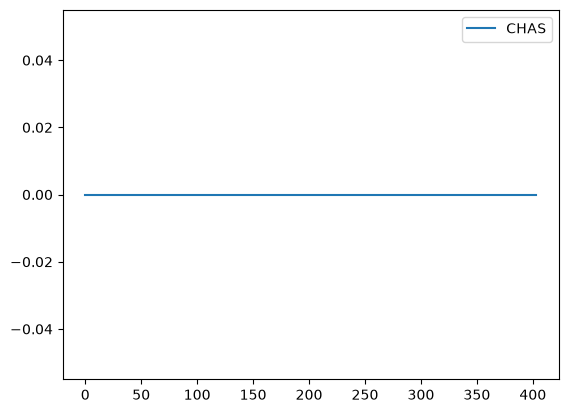

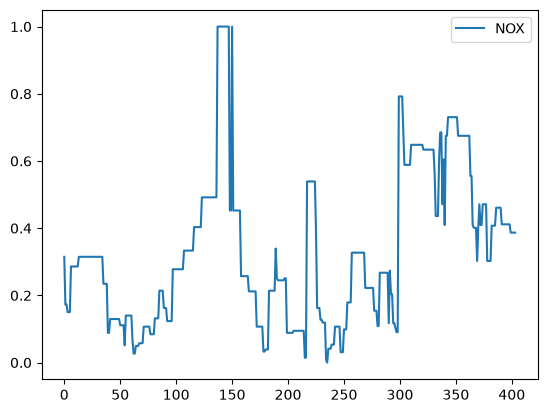

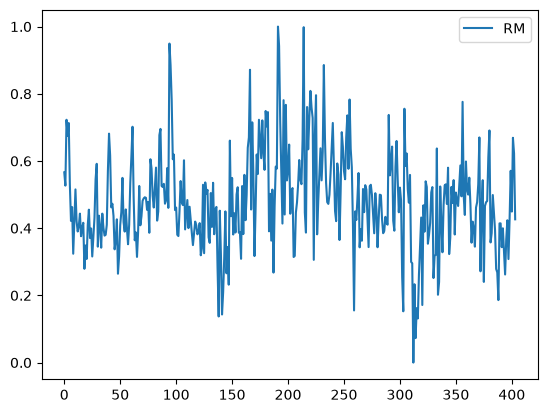

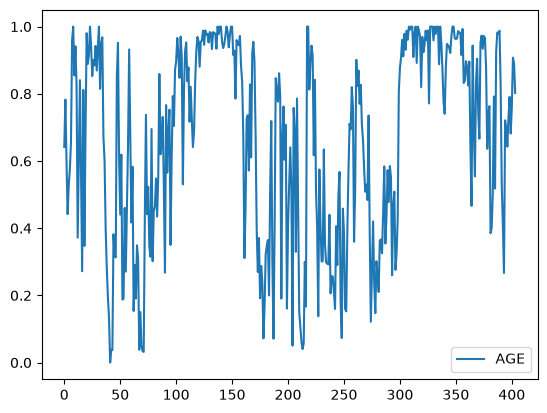

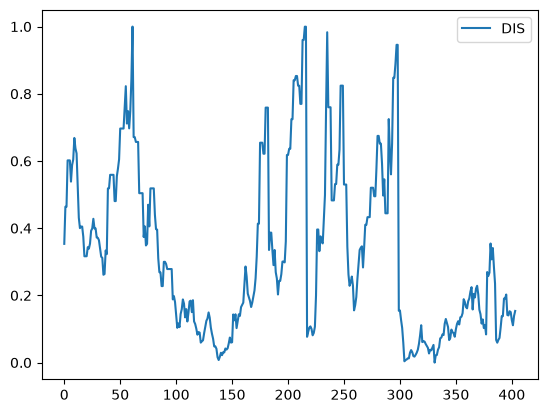

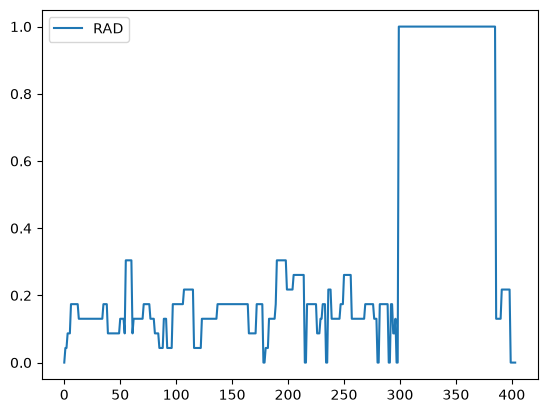

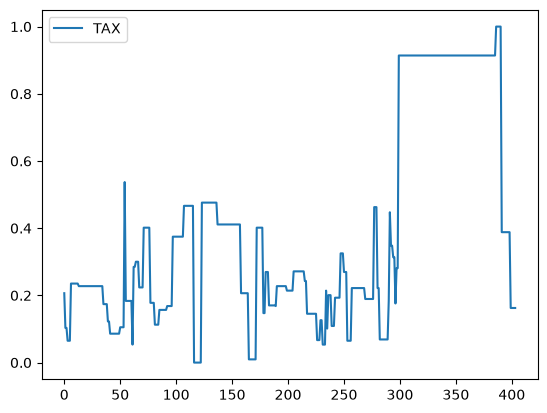

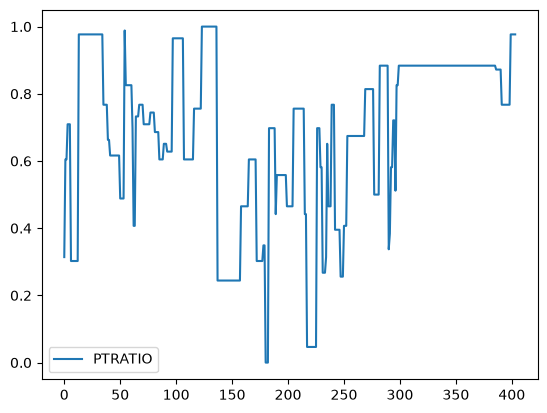

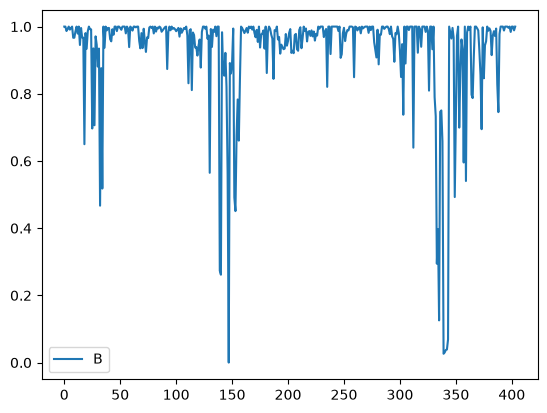

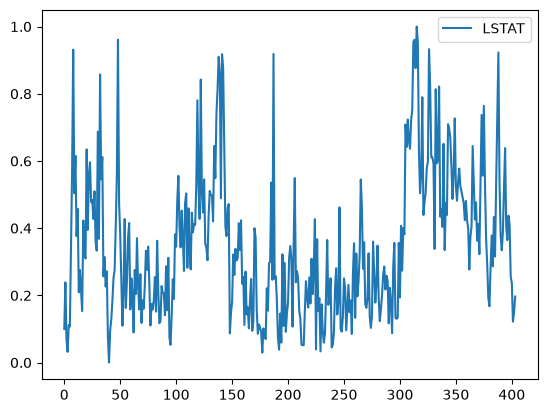

In [116]:
for col in X_Norm.columns:
    X_Norm[[col]].plot()
    plt.show()

In [117]:
STD = StandardScaler()
X_STD = STD.fit_transform(X)

In [118]:
X_STD = pd.DataFrame(data=X_STD,columns=X.columns)

<Axes: >

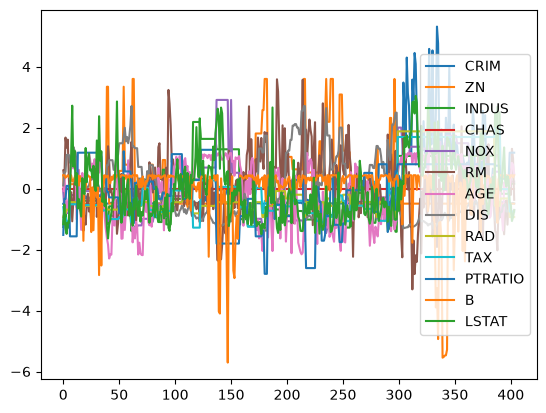

In [119]:
X_STD.plot()

X | X_Norm | X_STD

# 3) Train || [Develop]  Test || [Evaluation] Split

In [120]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.25 , random_state = 42 ) 
# Normal state

In [121]:
NX_train , NX_test , NY_train , NY_test = train_test_split(X_Norm , Y , test_size=0.25 , random_state = 42 )
# Normalized Scaled

In [122]:
SX_train , SX_test , SY_train , SY_test = train_test_split(X_STD , Y , test_size=0.25 , random_state = 42 )
# Standardized Scaled

# 4) Model

In [123]:
LR = LinearRegression()

In [124]:
LR.fit(X_train , Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.12, 0.01,-0.03,...,-0.79, 0.01,-0.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.51
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [125]:
LR.coef_

array([-1.15769270e-01,  9.85095385e-03, -2.78353630e-02,  3.32373018e-14,
       -7.79787896e+00,  5.69690397e+00, -3.64197811e-02, -9.41677553e-01,
        1.49821438e-01, -1.11501459e-02, -7.91381739e-01,  6.16477556e-03,
       -2.48035112e-01])

In [126]:
LR.intercept_

np.float64(15.507246974962849)

In [127]:
LR.score(X_test , Y_test) # Linear model is able to reduce 76.6% error as compared with base model
# error is diference between actual vs prediction 
# Base model is when we do prediction on average [predict average of price column for all records]
# R_Square [R2_score]

0.7668855359907769

In [128]:
Pred = LR.predict(X_test)

In [129]:
Pred # predictions for X_test columns 

array([24.79457897, 32.13754415, 17.27283593, 14.62139021, 25.9297136 ,
       27.87341069, 14.39115599, 14.79947052, 15.2402293 , 18.35906887,
       16.43552184, 25.42731408, 22.79800846, 10.66970675, 24.68395596,
       33.67036637, 32.24750626, 16.60864   , 19.56865456, 22.92626327,
       21.79404467, 23.91362076, 32.74324001, 37.937726  , 20.02055914,
       23.65436465, 24.54322553, 21.87338769, 31.06349874, 18.84979079,
       15.67768296, 36.23172452, 28.6082088 , 18.90502227, 27.91439551,
       16.89879832, 20.18678245, 11.51973727, 27.27640857, 18.58561707,
       18.63421797,  5.43556561, 16.44885245, 19.67573493, 17.29716207,
       18.36877026, 13.90172373, 15.75896558, 29.93270769, 19.44590114,
       17.07663493, 17.20921544, 20.95383954, 21.36907378, 21.02966875,
       16.85898667, 21.819473  , 23.32088867, 29.0390993 , 26.65357437,
       17.16775132, 31.92824156, 13.2596332 , 21.36224421, 12.13046914,
       36.60213631, 21.30076894, 21.57439454, 17.59194478, 25.28

In [130]:
Y_test # actual for X_test columns 

73     23.4
259    30.1
486    19.1
33     13.1
42     25.3
       ... 
265    22.8
197    30.3
298    22.5
479    21.4
362    20.8
Name: Price, Length: 101, dtype: float64

# Evaluation

In [131]:
print('MSE [Mean Squared Error] :' , mean_squared_error(Y_test , Pred )) # sigma((Y-Y^)^2)
print('MAE [Mean Absolute Error] :' , mean_absolute_error(Y_test , Pred )) # sigma(|Y-Y^|)
print('RMSE [Root Mean Squared Error] :' , mean_squared_error(Y_test , Pred )**0.5) # sqrt(sigma((Y-Y^)^2))
print('R Squared Value :' , LR.score(X_test , Y_test))

MSE [Mean Squared Error] : 10.857117059946393
MAE [Mean Absolute Error] : 2.531259404910289
RMSE [Root Mean Squared Error] : 3.2950139696132386
R Squared Value : 0.7668855359907769


In [132]:
LR = LinearRegression()
LR.fit(NX_train , NY_train)
NPred = LR.predict(NX_test)
print('MSE [Mean Squared Error] :' , mean_squared_error(Y_test , NPred ))
print('MAE [Mean Absolute Error] :' , mean_absolute_error(Y_test , NPred ))
print('RMSE [Root Mean Squared Error] :' , mean_squared_error(Y_test , NPred )**0.5)
print('R Squared Value :' , LR.score(NX_test , NY_test))

MSE [Mean Squared Error] : 10.857117059946356
MAE [Mean Absolute Error] : 2.5312594049102817
RMSE [Root Mean Squared Error] : 3.2950139696132332
R Squared Value : 0.7668855359907776


In [133]:
LR = LinearRegression()
LR.fit(SX_train , SY_train)
SPred = LR.predict(SX_test)
print('MSE [Mean Squared Error] :' , mean_squared_error(Y_test , SPred ))
print('MAE [Mean Absolute Error] :' , mean_absolute_error(Y_test , SPred ))
print('RMSE [Root Mean Squared Error] :' , mean_squared_error(Y_test , SPred )**0.5)
print('R Squared Value :' , LR.score(SX_test , Y_test))

MSE [Mean Squared Error] : 10.857117059946345
MAE [Mean Absolute Error] : 2.5312594049102803
RMSE [Root Mean Squared Error] : 3.2950139696132315
R Squared Value : 0.7668855359907779


In [134]:
pd.DataFrame({"Actual_Price":Y_test , "Predicted_Price" : Pred , "NormPrice" : NPred , "StdPrice" : SPred })

,Actual_Price,Predicted_Price,NormPrice,StdPrice
73,23.4,24.794579,24.794579,24.794579
259,30.1,32.137544,32.137544,32.137544
486,19.1,17.272836,17.272836,17.272836
33,13.1,14.621390,14.621390,14.621390
42,25.3,25.929714,25.929714,25.929714
...,...,...,...,...
265,22.8,25.321938,25.321938,25.321938
197,30.3,32.077974,32.077974,32.077974
298,22.5,27.133668,27.133668,27.133668
479,21.4,18.294948,18.294948,18.294948


# Adjusted R-squared = 1 − (1 − R²) × (n − 1) / (n − k − 1)

In [135]:
K = 1
n = X.shape[0]
Adj_R2s = []
for i in range(len(X.columns)):
    Rx = X.iloc[:,0:K]
    xtrain , xtest , ytrain , ytest =  train_test_split(Rx,Y,test_size=0.25,random_state=42)
    LR = LinearRegression()
    LR.fit(xtrain , ytrain)
    R2 =  LR.score(xtest , ytest )
    Adj_R2 = 1-(1-R2)*(n-1) / (n-K-1)
    Adj_R2s.append(Adj_R2)
    K+=1

In [136]:
x_axis=list(range(1,len(Adj_R2s)+1))

In [137]:
y_axis=Adj_R2s

Text(0, 0.5, 'R2 value')

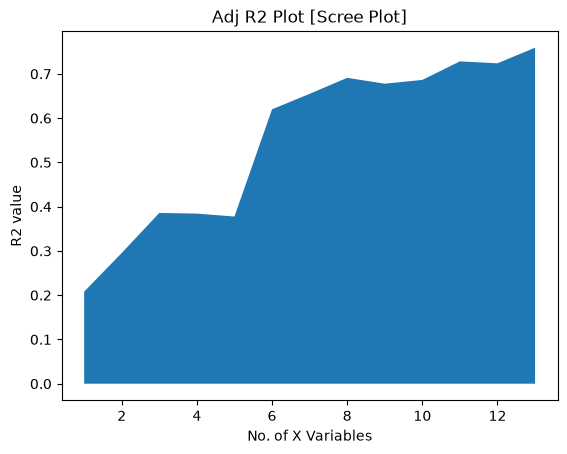

In [138]:
plt.fill_between(x_axis,y_axis)
plt.title('Adj R2 Plot [Scree Plot]')
plt.xlabel("No. of X Variables")
plt.ylabel("R2 value")

In [139]:
DX=X.drop(["NOX","RAD"],axis=1)

In [140]:
xtrain , xtest , ytrain , ytest =  train_test_split(DX,Y,test_size=0.25,random_state=42)
LR = LinearRegression()
LR.fit(xtrain , ytrain)
R2 =  LR.score(xtest , ytest )

In [141]:
R2

0.7467218795820554

<Axes: >

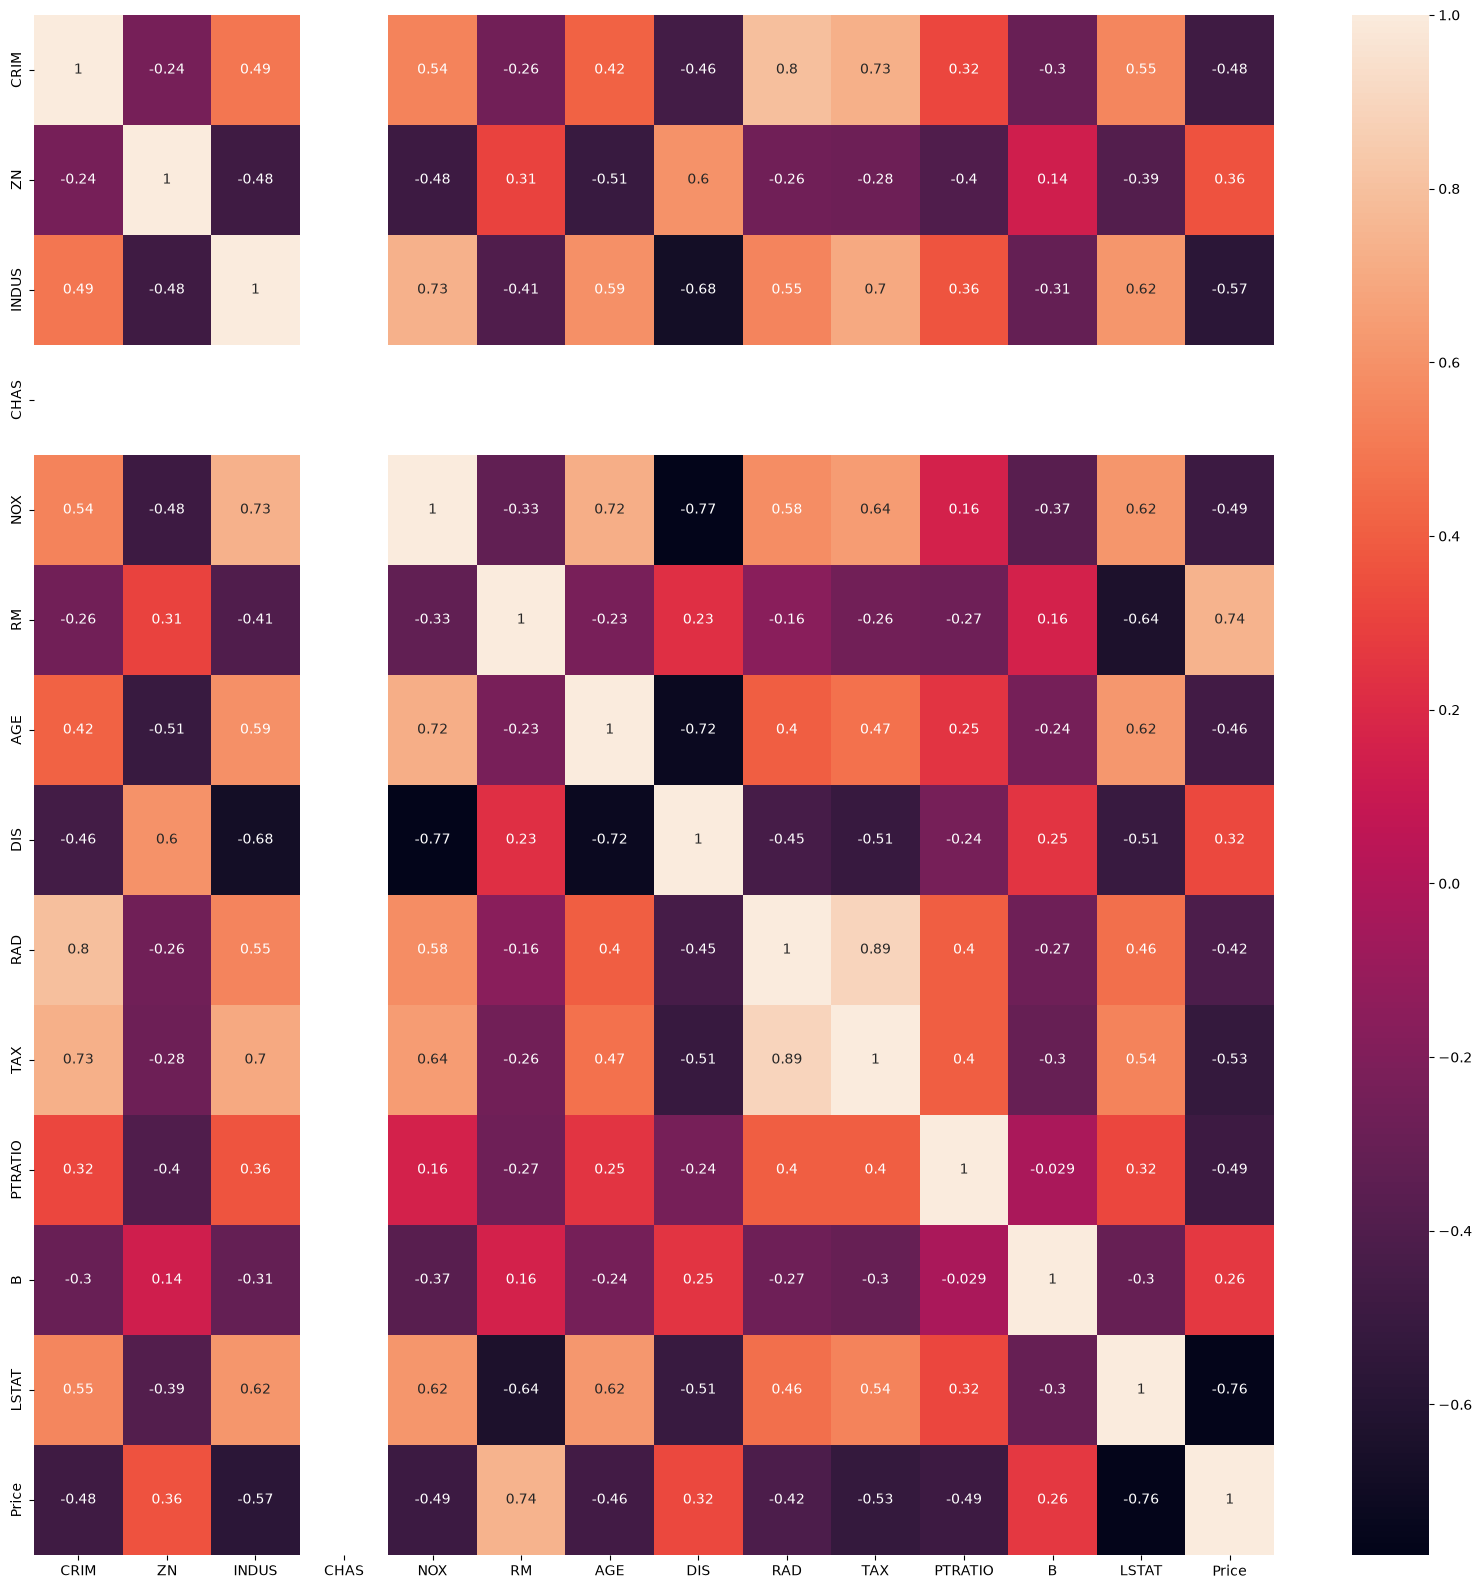

In [142]:
plt.figure(figsize=(20,20))
sns.heatmap(BS.corr(),annot=True)

In [143]:
DX=X[['RM','LSTAT','INDUS','TAX','PTRATIO','RAD','AGE','NOX','CRIM','ZN']]

In [144]:
xtrain , xtest , ytrain , ytest =  train_test_split(DX,Y,test_size=0.25,random_state=42)
LR = LinearRegression()
LR.fit(xtrain , ytrain) # will get ceof and intercept to calculate prediction
R2 =  LR.score(xtest , ytest ) # findind R2 value

In [145]:
R2

0.7365605930022352

# Regularization Techniques

In [146]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [147]:
L1= Ridge()
L2=Lasso()
EN=ElasticNet()

In [148]:
xtrain,xtest, ytrain,ytest= train_test_split(X_STD,Y,test_size=0.25,random_state=42)

In [149]:
L1.fit(xtrain,ytrain)
print("L1 Training R2 Value :",L1.score(xtrain,ytrain))
print("L1 Testing R2 Value :",L1.score(xtest,ytest))

L1 Training R2 Value : 0.7955624453200689
L1 Testing R2 Value : 0.7666339189615305


In [150]:
L2.fit(xtrain,ytrain)
print("L2 Training R2 Value :",L2.score(xtrain,ytrain))
print("L2 Testing R2 Value :",L2.score(xtest,ytest))

L2 Training R2 Value : 0.7278525245342683
L2 Testing R2 Value : 0.7278196651359962


In [151]:
EN.fit(xtrain,ytrain)
print("EN Training R2 Value :",EN.score(xtrain,ytrain))
print("EN Testing R2 Value :",EN.score(xtest,ytest))

EN Training R2 Value : 0.7086316671332052
EN Testing R2 Value : 0.712479541589877


# Ridge Lossfn(Y-Y^)^2+/|*(slope)*2

In [152]:
prop=28 # actual price is y
pred=22 # prediction Y^

In [153]:
(28-22)**2+1*50

86

In [154]:
LR.intercept_

np.float64(8.324169952149802)

In [155]:
L1_pred= L1.predict(xtest)
L2_pred= L2.predict(xtest)
EN_pred= EN.predict(xtest)

In [156]:
actual= ytest

<Axes: xlabel='Price'>

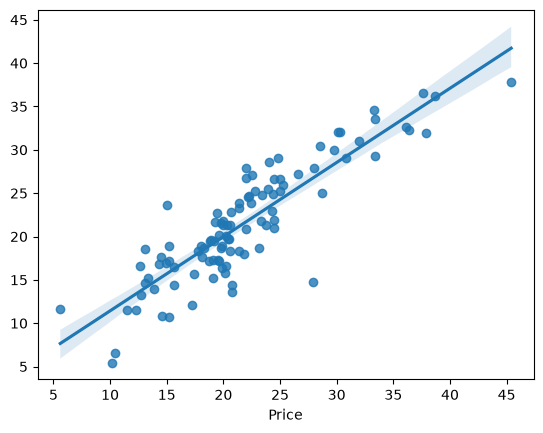

In [157]:
sns.regplot(x=actual,y=L1_pred)

<Axes: xlabel='Price'>

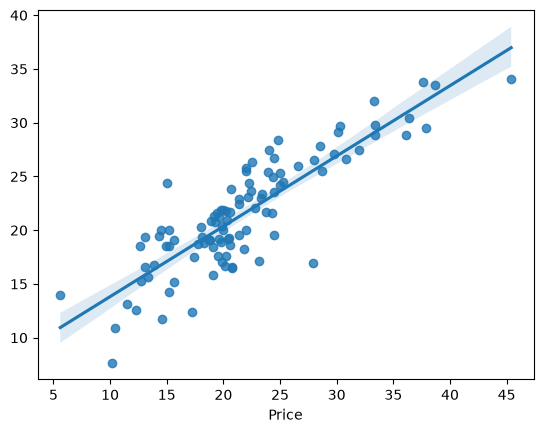

In [158]:
sns.regplot(x=actual,y=L2_pred)

<Axes: xlabel='Price'>

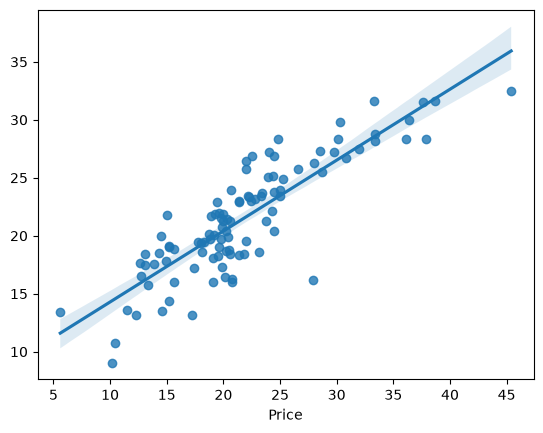

In [159]:
sns.regplot(x=actual,y=EN_pred)

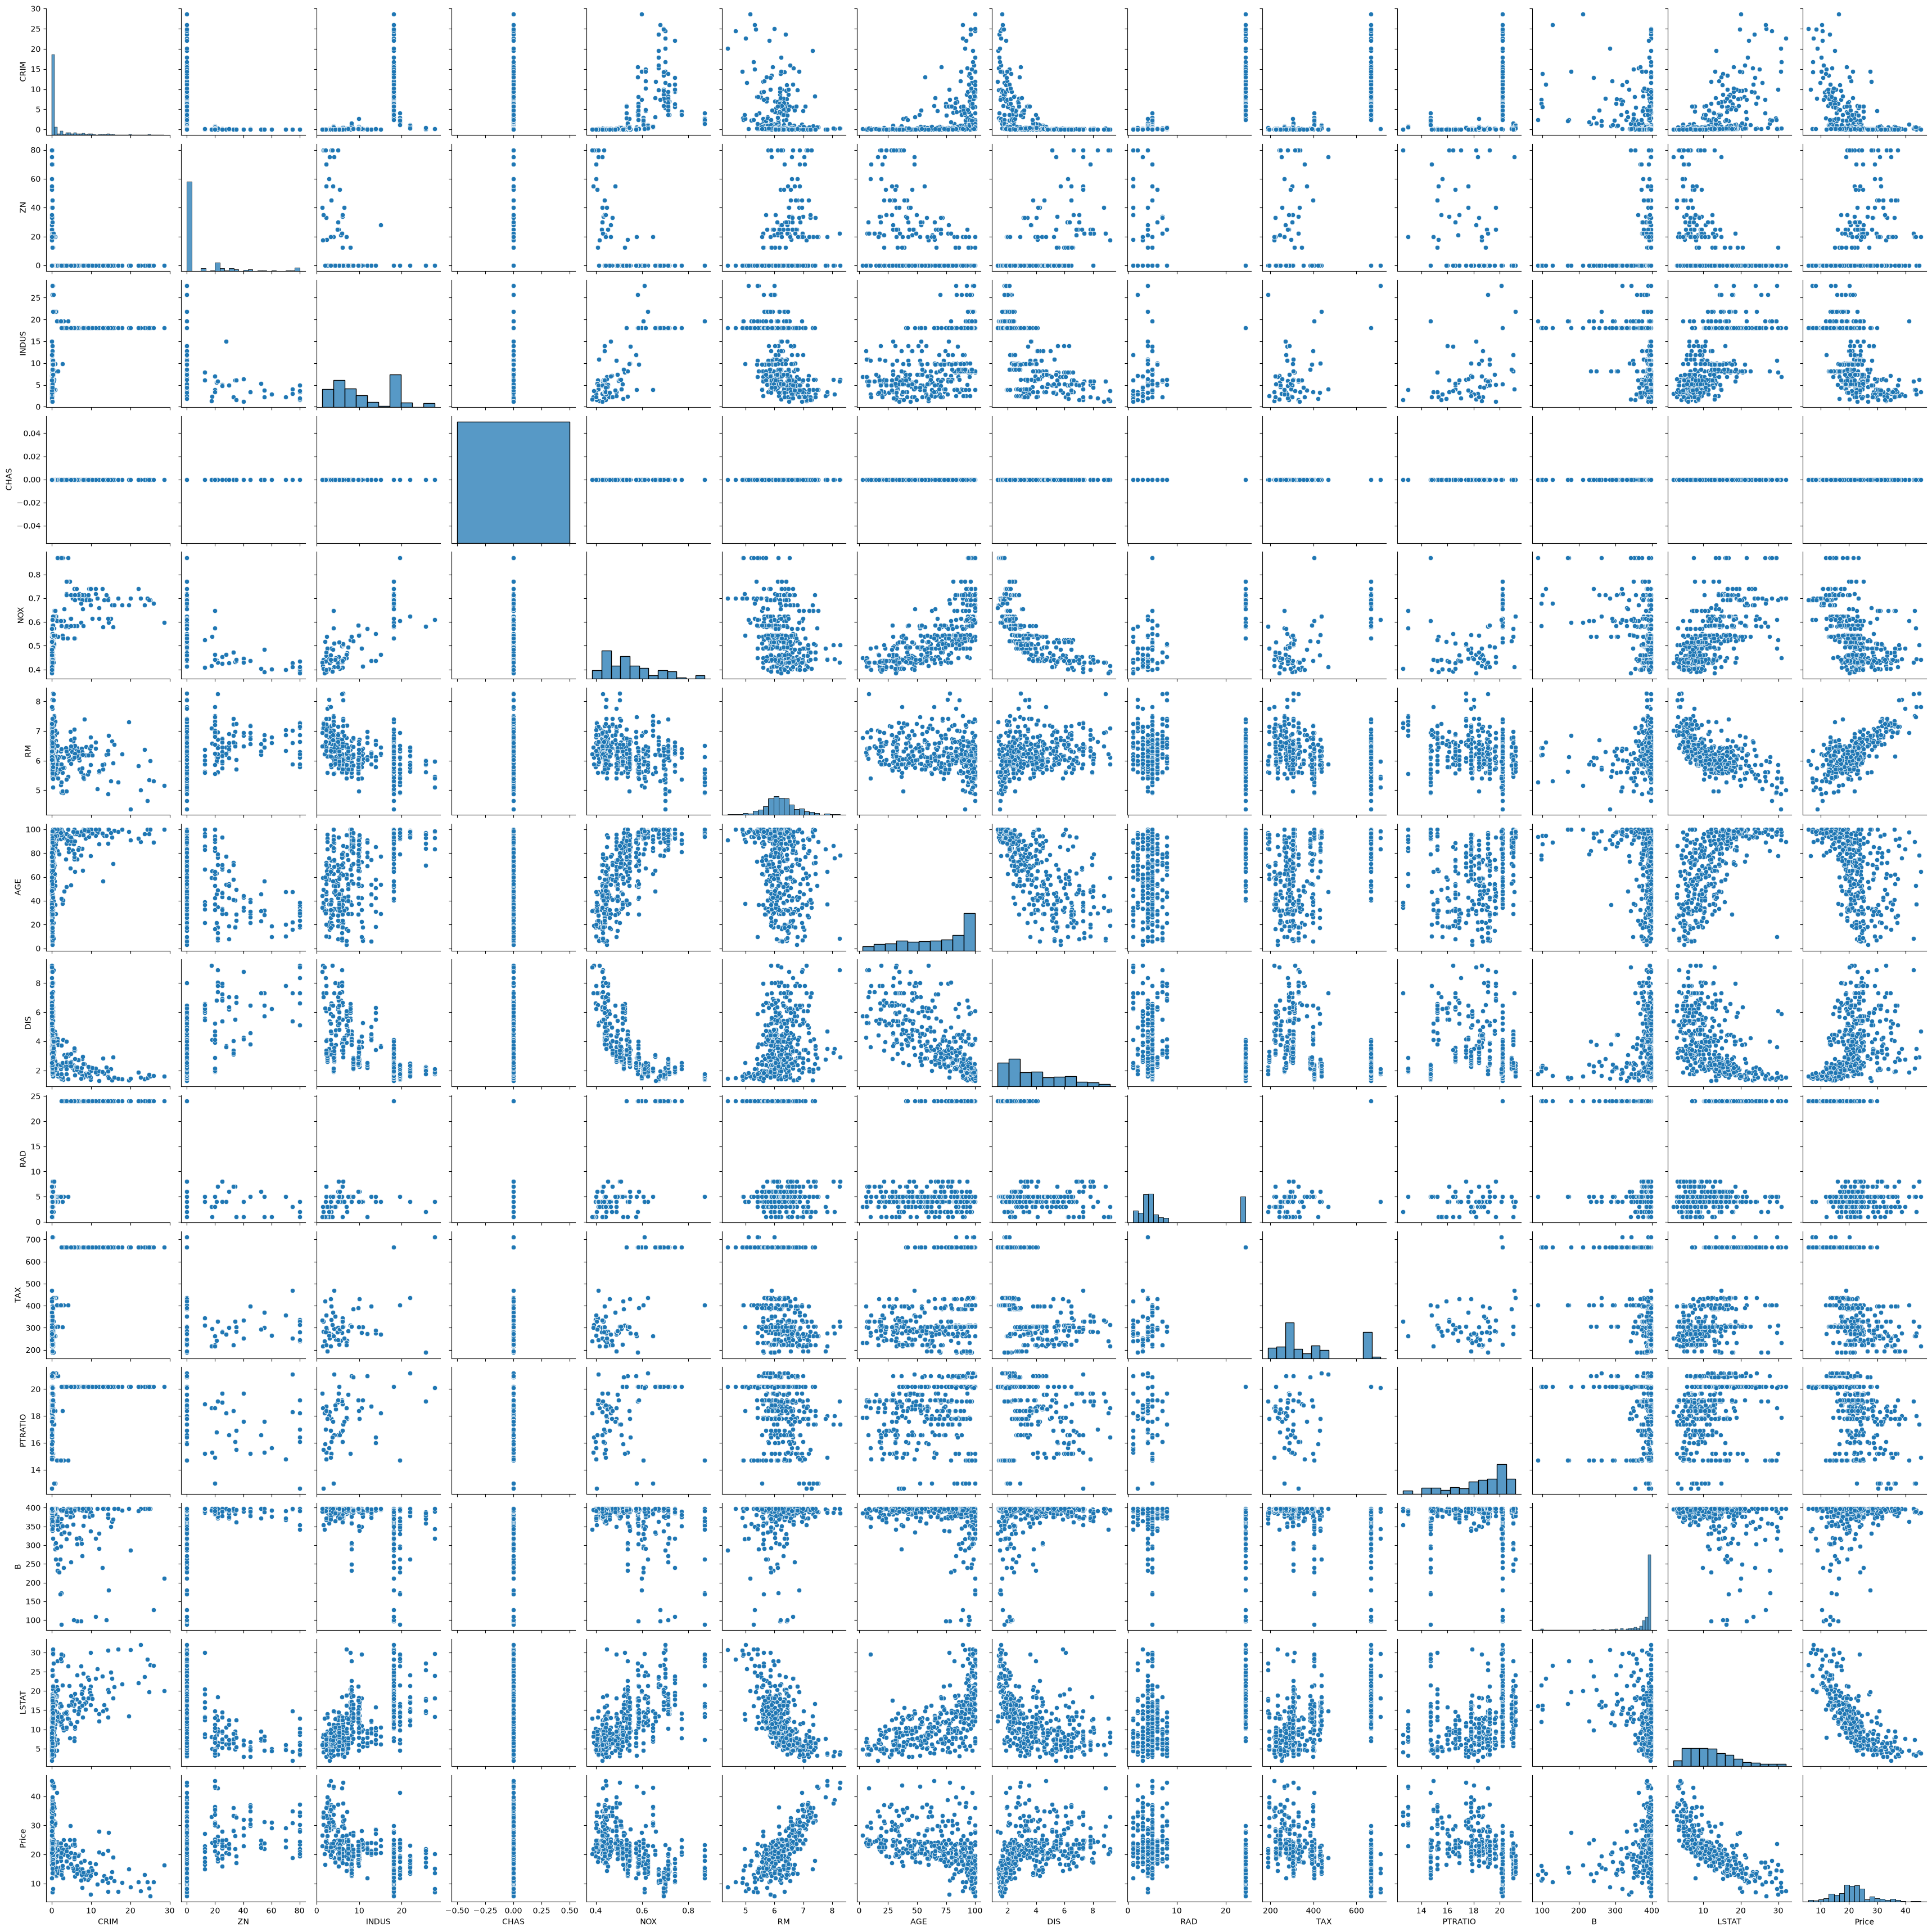

In [160]:
sns.pairplot(BS)

# Conclusion

1) Data Aquisition[CSV File]
2) Data cleaning and preprocessing
   * Data Type[X data should have all numeric records ]
   * Missing data treat[Data should not have any missing record]
   * outliers[Data should have any unexpected cases(NOISE)]
3) Train test split
   * X independent data [by which we do prediction]
   * Y dependet data [whihc we are predicting]
   * Training data is used to train model.
   * Testing data is used to evaluate Model.
4) Model create using Linear Regression
   * Cofficient[M value]
   * Intercept[C value]
   * M1*x1 + M2*x2 + M3*x3........+C[Formula for prediction]
5) Performance Testing
   * MSE[Mean squared error]
   * MAE[Mean absolute error]
   * RMSE[Root mean squared error]
   * R2[R squared value]
   * Adj R2[Adjusted R_squared value]
6) Optimization and Regularization   
   * Optimize: try to increase R2 value selection of columns on the basis of coorelation with Y
   * Regularization: reduce the different between Train_R2 value and Testing R2_value
   * Overfitting: when model is performing good in training but bad at the time of testing.
7) Deployment

# interview based questions
* Q1 what all are the types  of Linear Regression?
Ans. 1)Simple Linear Regression where we havr single columns X data
2)Multiple Linear Regression where we have more than 1 column in X Data

Q2) What is the equation for simple Linear Regression and Multiple Linear Regression?
1) Mx+C Simple Linear Regression
2) M1x1+M2x2+M3x3.....+C is the multiple Linear Regression.

Q3) What is the step of cleaning and preprocessing of data for linear model?
Ans : Data Profilling [Selection of correct data types]
        Machine understands numbe only so hence we will convert all categorical data into Numerical.

Q4) Before using Linear Regression what all are the points that we have to check?
Ans:
1) there should be a linear relationship between X and Y.
2) Error terms should be normally distributed[No Outliers]
3) There should be a Homoscedascisity in Data [all data should be near to linear line]
4) there should not be a problem of Multicolinearity [X1 is correlated with x2,x3,x4,x5....]
5) all cloumns of independent data should be act independently.


Q5) Step by step define data cleaing and preprocessing?
1) data profilling.
   * all catagorical data should be converted to numeric
2) missing value
3) outliers
4) Correlation[Feature Engineering]
5) Feature scalling

Q6) List the Performance Metrics for Linear Regression?
Ans: 
1) MSE[MEAN SQAURED ERROR]
2) RMSE[ROOT MEAN SQUARD ERROR]
3) MAE[MEAN ABSOLUTE ERROR]
4) R2[R SQUARED VALUE]
5) ADJUSTED R SQUARED VALUE

Q7) What is the difference between Loss and cost Function?
Ans: Loss functions defines error of single prediction whereas Cost function defines error of all predictions.

Q8) What is the difference between overfitting and underfitting?
Ans: Overfitting when the model is performing good at training but lapse at the time of testing.
Underfitting when the model not good in both training and testing.

In [161]:
import pickle

In [168]:
LR.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.12, 0.01,-0.03,...,-0.79, 0.01,-0.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.51
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [169]:
LR.coef_

array([-1.15769270e-01,  9.85095385e-03, -2.78353630e-02,  3.32373018e-14,
       -7.79787896e+00,  5.69690397e+00, -3.64197811e-02, -9.41677553e-01,
        1.49821438e-01, -1.11501459e-02, -7.91381739e-01,  6.16477556e-03,
       -2.48035112e-01])

In [162]:
pickle.dump(LR,open('model.pkl','wb'))
pickle.dump(list(X.columns),open('columns.pkl','wb'))

In [163]:
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='str')

In [164]:
LR.coef_

array([ 5.91413353, -0.28688429,  0.02143803, -0.01157199, -0.78214447,
        0.12511945, -0.0186113 , -1.35669965, -0.06186335, -0.01597419])